In [1]:
import pysam
import numpy as np
import pandas as pd
import itertools
import re

from Bio import SeqIO
from Bio.Seq import Seq
from tqdm import tqdm
from collections import defaultdict

# import re
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy.stats as stats
# import os
# import mpl_scatter_density
# import statsmodels.api as sm
# from collections import Counter
# from scipy.stats import gaussian_kde, iqr
# from collections import defaultdict
# from patsy import dmatrices

In [2]:
working_path = "/home/wbguo/iproject/BSReadSim/test/"

ref_fasta = working_path + "/data/ref/GRCh38_full_analysis_set_plus_decoy_hla.fa"
bam_file  = working_path + "/data/RRBS/SRR6294859.sorted.bam"

In [3]:
cut_str   = 'C|CGG'

In [4]:
ref_dict  = SeqIO.to_dict(SeqIO.parse(ref_fasta, "fasta"))

# parse read pairs

In [5]:
def get_align_flag(align, mapq_thre =20):
    is_paired  = align.is_proper_pair
    is_mapped  = (not align.is_unmapped)
    is_primary = (not align.is_secondary) and (not align.is_supplementary)
    is_qualified = (not align.is_qcfail) and align.mapq >= mapq_thre
    is_fully_align = all(op in (0, 7, 8) for op, length in align.cigar)
    return is_paired and is_mapped and is_primary and is_qualified and is_fully_align


def read_pair_generator(bam_file, region_string=None):
    """
    Generate read pairs in a BAM file or within a region string.
    Reads are added to read_dict until a pair is found.
    """
    read_dict = defaultdict(lambda: [None, None])
    bam = pysam.AlignmentFile(bam_file, "rb")
    #bam.reset()
    
    for align in bam.fetch(until_eof=True, region=region_string):        
        if not get_align_flag(align):
            continue
        
        qname = align.query_name
        if qname not in read_dict.keys():
            read_dict[qname][int(align.is_read2)] = align
        else:
            read_dict[qname][int(align.is_read2)] = align
            yield read_dict[qname]
            del read_dict[qname]

                    
def gen_frag_df(bam_file, contig_id):
    read_pair_dict = {}
    
    for read1, read2 in read_pair_generator(bam_file, contig_id):
        pos_list   = [read1.reference_start, read1.reference_end, read2.reference_start, read2.reference_end]
        start, end = np.min(pos_list), np.max(pos_list)
        if (contig_id, start, end) in read_pair_dict:
            read_pair_dict[(contig_id, start, end)] += 1
        else:
            read_pair_dict[(contig_id, start, end)] = 1
    
    return pd.DataFrame([(*key, val) for key, val in read_pair_dict.items()])

In [6]:
chr_list = list(ref_dict.keys())[0:25]
frag_df_list = []

for contig_id in chr_list:
    frag_df_list.append(gen_frag_df(bam_file, contig_id))

In [7]:
frag_df =  pd.concat(frag_df_list, axis=0, ignore_index=True)
frag_df.columns = ['chr', 'start', 'end', 'count']

In [8]:
frag_df.loc[1:10,:]

,chr,start,end,count
1,chr1,51589,51674,52
2,chr1,51587,51721,2
3,chr1,51589,51723,5
4,chr1,88706,88852,10
5,chr1,134998,135216,6
6,chr1,137976,138007,1
7,chr1,181417,181470,1
8,chr1,181573,181677,2
9,chr1,182789,182849,33
10,chr1,182791,182851,36


# check and assign cut site

In [9]:
def check_boundary(contig_id, pos, site_list):
    offset  = max([len(site) for site in site_list])
    pos_l   = int(pos) - offset
    pos_r   = int(pos) + offset
    tmp_seq = ref_dict[contig_id][pos_l:pos_r].seq.upper()
    
    return sum([tmp_seq.count(site) for site in site_list])

In [10]:
def find_closest_cut(contig_id, pos, site_list, is_upstream = True, search_window = 500):
    offset  = max([len(site) for site in site_list])
    
    if is_upstream:
        pos_l = int(pos) - search_window
        pos_r = int(pos) + offset
        tmp_seq = ref_dict[contig_id][pos_l:pos_r].seq.upper()
        
        pos_list= []
        for ix, site in enumerate(site_list):
            pos_list.extend([match.start() for match in re.finditer(site, str(tmp_seq))])
        
        pos_arr = np.array(pos_list) - search_window
        cut_pos = np.nan if len(pos_arr)==0 else pos + pos_arr[np.argmin(np.abs(pos_arr))]
        return cut_pos
        
    else:
        pos_l = int(pos) - offset
        pos_r = int(pos) + search_window
        tmp_seq = ref_dict[contig_id][pos_l:pos_r].seq.upper()
        
        pos_list= []
        for ix, site in enumerate(site_list):
            pos_list.extend([match.start() + len(site) for match in re.finditer(site, str(tmp_seq))])
        
        pos_arr = np.array(pos_list) - offset
        cut_pos = np.nan if len(pos_arr)==0 else pos + pos_arr[np.argmin(np.abs(pos_arr))]
        return cut_pos

In [11]:
site_list = ['CCGG']

frag_df.loc[:, "flag_start"]= frag_df.apply(lambda x: check_boundary(x.chr, x.start, site_list), axis=1)
frag_df.loc[:, "flag_end"]  = frag_df.apply(lambda x: check_boundary(x.chr, x.end, site_list), axis=1)
frag_df.loc[:, "ref_l"] = frag_df.apply(lambda x: find_closest_cut(x.chr, x.start, site_list, is_upstream=True), axis=1)
frag_df.loc[:, "ref_r"] = frag_df.apply(lambda x: find_closest_cut(x.chr, x.end,  site_list, is_upstream=False), axis=1)

In [12]:
pd.set_option("display.max_rows", 20)

In [13]:
frag_df

,chr,start,end,count,flag_start,flag_end,ref_l,ref_r
0,chr1,51587,51672,47,1,0,51586.0,51724.0
1,chr1,51589,51674,52,1,0,51586.0,51724.0
2,chr1,51587,51721,2,1,1,51586.0,51724.0
3,chr1,51589,51723,5,1,1,51586.0,51724.0
4,chr1,88706,88852,10,1,1,88703.0,88853.0
...,...,...,...,...,...,...,...,...
468068,chrM,16260,16455,1,0,1,15924.0,16456.0
468069,chrM,16361,16455,1,0,1,15924.0,16456.0
468070,chrM,16376,16453,1,0,1,15924.0,16456.0
468071,chrM,16378,16455,2,0,1,15924.0,16456.0


In [14]:
pd.set_option("display.max_rows", None)

In [15]:
frag_df.loc[0:100,:]

,chr,start,end,count,flag_start,flag_end,ref_l,ref_r
0,chr1,51587,51672,47,1,0,51586.0,51724.0
1,chr1,51589,51674,52,1,0,51586.0,51724.0
2,chr1,51587,51721,2,1,1,51586.0,51724.0
3,chr1,51589,51723,5,1,1,51586.0,51724.0
4,chr1,88706,88852,10,1,1,88703.0,88853.0
5,chr1,134998,135216,6,1,1,134997.0,135219.0
6,chr1,137976,138007,1,1,0,137975.0,138268.0
7,chr1,181417,181470,1,0,0,181322.0,181574.0
8,chr1,181573,181677,2,1,1,181570.0,181678.0
9,chr1,182789,182849,33,0,1,182477.0,182852.0


In [16]:
pd.set_option("display.max_rows", 20)

# calculate length, count, cg ratio, #cuts

In [17]:
{site: 0 for site in site_list}

{'CCGG': 0}

In [18]:
def cal_gc_ratio(contig_id, pos_l, pos_r):
    tmp_seq = ref_dict[contig_id][int(pos_l):int(pos_r)].seq.upper()
    cg_count= tmp_seq.count("C") + tmp_seq.count("G")
    return cg_count/(pos_r - pos_l)

def cal_num_cuts(contig_id, pos_l, pos_r, site_list):
    tmp_seq  = ref_dict[contig_id][int(pos_l):int(pos_r)].seq.upper()
    site_dict= {site: 0 for site in site_list}
    for site in site_dict.keys():
        site_dict[site] = tmp_seq.count(site)
    return list(site_dict.values())

In [19]:
keep_idx = np.logical_not(np.isnan(frag_df.ref_l) | np.isnan(frag_df.ref_r))
frag_cut_df = frag_df.loc[keep_idx, :].groupby(['chr', 'ref_l', 'ref_r'])['count'].sum().reset_index()
frag_cut_df.loc[:, "length"]  = frag_cut_df.ref_r - frag_cut_df.ref_l
frag_cut_df.loc[:, "gc_ratio"]= frag_cut_df.apply(lambda x: cal_gc_ratio(x.chr, x.ref_l, x.ref_r), axis=1)
site_num_df = frag_cut_df.apply(lambda x: cal_num_cuts(x.chr, x.ref_l, x.ref_r, site_list), axis=1, result_type='expand')
site_num_df.columns = site_list
frag_cut_df = pd.concat([frag_cut_df, site_num_df], axis=1)
frag_cut_df.loc[:, "log_count"] = np.log2(frag_cut_df.loc[:, "count"]+1)

In [20]:
from scipy.stats import gaussian_kde, iqr
max_coverage = np.quantile(frag_cut_df['count'], 0.75) + 1.5*iqr(frag_cut_df['count'])
min_coverage = np.quantile(frag_cut_df['count'], 0.25) - 1.5*iqr(frag_cut_df['count'])

max_log_coverage = np.quantile(frag_cut_df['log_count'], 0.75) + 1.5*iqr(frag_cut_df['log_count'])

In [21]:
frag_cut_df.loc[:, 'count'].describe()

count    293029.000000
mean         15.917786
std          54.258020
min           1.000000
25%           3.000000
50%          10.000000
75%          22.000000
max       12634.000000
Name: count, dtype: float64

In [22]:
frag_cut_df.loc[:, 'log_count'].describe()

count    293029.000000
mean          3.295567
std           1.513252
min           1.000000
25%           2.000000
50%           3.459432
75%           4.523562
max          13.625138
Name: log_count, dtype: float64

In [23]:
max_coverage

50.5

In [24]:
min_coverage

-25.5

In [25]:
max_log_coverage

8.308904890142532

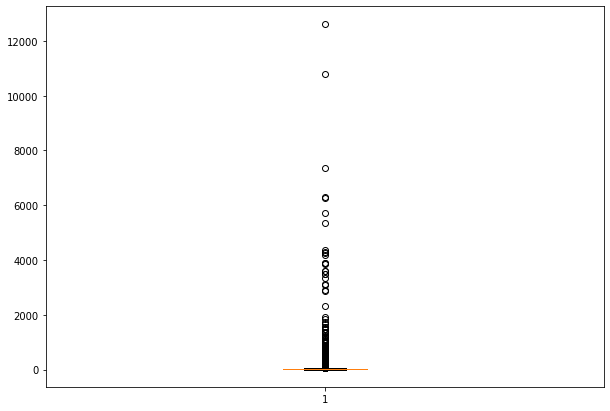

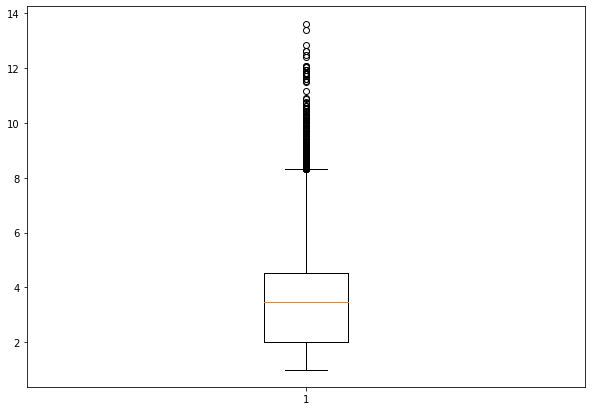

In [26]:
import matplotlib.pyplot as plt
import numpy as np
 
# Creating dataset
fig = plt.figure(figsize =(10, 7))

# Creating plot
plt.boxplot(frag_cut_df.loc[:, 'count'])
# show plot
plt.show()


# Creating dataset
fig = plt.figure(figsize =(10, 7))
# Creating plot
plt.boxplot(frag_cut_df.loc[:, 'log_count'])
# show plot
plt.show()

# on the count

In [27]:
frag_cut_df2 = frag_cut_df.loc[frag_cut_df.loc[:,"count"] < max_coverage,:]
frag_cut_df2.loc[:, "relative_depth"] = frag_cut_df2.loc[:, "count"]/max_coverage

/home/wbguo/.local/lib/python3.8/site-packages/pandas/core/indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


In [28]:
frag_cut_df2

,chr,ref_l,ref_r,count,length,gc_ratio,CCGG,log_count,relative_depth
1,chr1,88703.0,88853.0,10,150.0,0.666667,2,3.459432,0.198020
2,chr1,134997.0,135219.0,6,222.0,0.671171,2,2.807355,0.118812
3,chr1,137975.0,138268.0,1,293.0,0.672355,2,1.000000,0.019802
4,chr1,181322.0,181574.0,1,252.0,0.726190,2,1.000000,0.019802
5,chr1,181570.0,181678.0,2,108.0,0.759259,2,1.584963,0.039604
...,...,...,...,...,...,...,...,...,...
293024,chrY,24276285.0,24276458.0,11,173.0,0.653179,2,3.584963,0.217822
293025,chrY,26403637.0,26404260.0,2,623.0,0.646870,2,1.584963,0.039604
293026,chrY,26610489.0,26611056.0,22,567.0,0.470899,2,4.523562,0.435644
293027,chrY,56874939.0,56875077.0,3,138.0,0.521739,2,2.000000,0.059406


In [29]:
frag_cut_df2.loc[:, 'count'].describe()

count    281486.000000
mean         12.952559
std          12.178965
min           1.000000
25%           3.000000
50%           9.000000
75%          20.000000
max          50.000000
Name: count, dtype: float64

In [30]:
frag_cut_df2.gc_ratio.describe()

count    281486.000000
mean          0.584341
std           0.082914
min           0.265625
25%           0.528571
50%           0.571429
75%           0.641509
max           0.972973
Name: gc_ratio, dtype: float64

<AxesSubplot:>

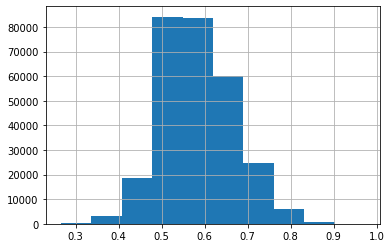

In [31]:
frag_cut_df2.gc_ratio.hist()

In [32]:
frag_cut_df2.relative_depth.describe()

count    281486.000000
mean          0.256486
std           0.241168
min           0.019802
25%           0.059406
50%           0.178218
75%           0.396040
max           0.990099
Name: relative_depth, dtype: float64

<AxesSubplot:>

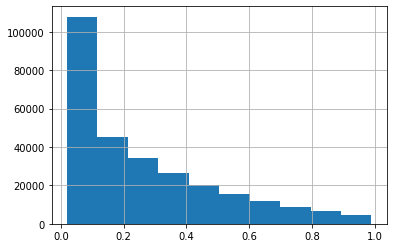

In [33]:
frag_cut_df2.relative_depth.hist()

In [34]:
frag_cut_df2.CCGG.describe()

count    281486.000000
mean          2.021905
std           0.149449
min           2.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           7.000000
Name: CCGG, dtype: float64

<AxesSubplot:>

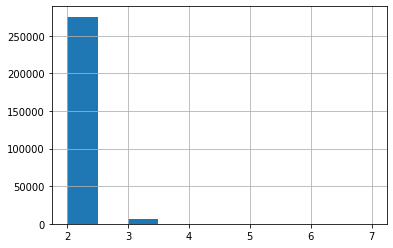

In [35]:
frag_cut_df2.CCGG.hist()

In [36]:
frag_cut_df2.length.describe()

count    281486.000000
mean        192.626649
std         105.236780
min         104.000000
25%         136.000000
50%         160.000000
75%         207.000000
max        1033.000000
Name: length, dtype: float64

<AxesSubplot:>

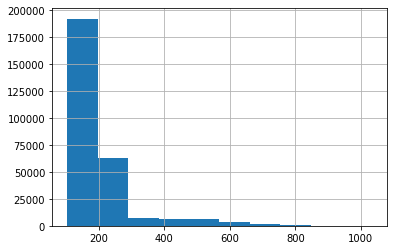

In [37]:
frag_cut_df2.length.hist()

<AxesSubplot:>

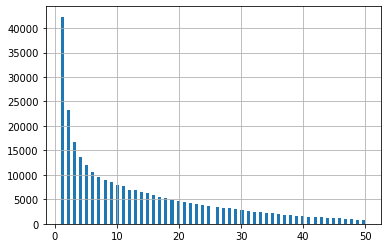

In [38]:
frag_cut_df2.loc[:, 'count'].hist(bins=100)

<AxesSubplot:>

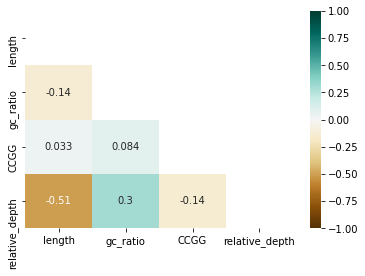

In [39]:
import seaborn as sns
%matplotlib inline

corr = frag_cut_df2.loc[frag_cut_df2.loc[:,"count"]>0,["length","gc_ratio", "CCGG", "relative_depth"]].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

# plot the heatmap
sns.heatmap(corr,  vmin=-1, vmax=1, annot=True, cmap='BrBG', mask=mask,
            xticklabels=corr.columns,
            yticklabels=corr.columns)

In [65]:
frag_cut_df2

,chr,ref_l,ref_r,count,length,gc_ratio,CCGG,log_count,relative_depth
1,chr1,88703.0,88853.0,10,150.0,0.666667,2,3.459432,0.198020
2,chr1,134997.0,135219.0,6,222.0,0.671171,2,2.807355,0.118812
3,chr1,137975.0,138268.0,1,293.0,0.672355,2,1.000000,0.019802
4,chr1,181322.0,181574.0,1,252.0,0.726190,2,1.000000,0.019802
5,chr1,181570.0,181678.0,2,108.0,0.759259,2,1.584963,0.039604
...,...,...,...,...,...,...,...,...,...
293024,chrY,24276285.0,24276458.0,11,173.0,0.653179,2,3.584963,0.217822
293025,chrY,26403637.0,26404260.0,2,623.0,0.646870,2,1.584963,0.039604
293026,chrY,26610489.0,26611056.0,22,567.0,0.470899,2,4.523562,0.435644
293027,chrY,56874939.0,56875077.0,3,138.0,0.521739,2,2.000000,0.059406


In [66]:
frag_cut_df2.to_csv("/home/wbguo/iproject/BSReadSim/test/data/RRBS/frag_cut_df2.csv", 
                    index = None, header=True, quoting=None)

# linear regression

In [68]:
from patsy import dmatrices
import statsmodels.api as sm

In [69]:
y, X = dmatrices('relative_depth ~ gc_ratio + length + CCGG', 
                 data = frag_cut_df2,
                 return_type='dataframe')

In [70]:
mod = sm.OLS(y, X)
mod = mod.fit()
print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:         relative_depth   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                 1.560e+04
Date:                Fri, 24 Feb 2023   Prob (F-statistic):               0.00
Time:                        13:16:44   Log-Likelihood:                 22578.
No. Observations:              281486   AIC:                        -4.515e+04
Df Residuals:                  281482   BIC:                        -4.511e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2990      0.006     47.368      0.0

In [71]:
X

,Intercept,gc_ratio,length,CCGG
1,1.0,0.666667,150.0,2.0
2,1.0,0.671171,222.0,2.0
3,1.0,0.672355,293.0,2.0
4,1.0,0.726190,252.0,2.0
5,1.0,0.759259,108.0,2.0
...,...,...,...,...
293024,1.0,0.653179,173.0,2.0
293025,1.0,0.646870,623.0,2.0
293026,1.0,0.470899,567.0,2.0
293027,1.0,0.521739,138.0,2.0


In [72]:
y

,relative_depth
1,0.198020
2,0.118812
3,0.019802
4,0.019802
5,0.039604
...,...
293024,0.217822
293025,0.039604
293026,0.435644
293027,0.059406


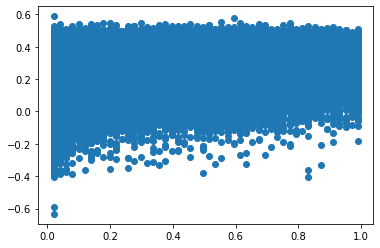

In [73]:
plt.scatter(y, mod.predict(X))
plt.show()

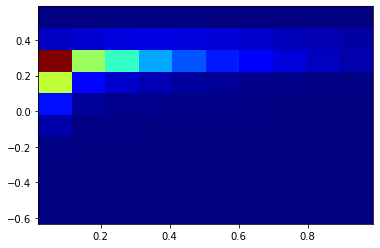

In [74]:
plt.hist2d(np.squeeze(y.to_numpy()), mod.predict(X), cmap=plt.cm.jet)
plt.show()

# quantile regression

In [75]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [76]:
mod = smf.quantreg('relative_depth ~ CCGG + length + gc_ratio', frag_cut_df2)
res = mod.fit(q=.5)
print(res.summary())

                         QuantReg Regression Results                          
Dep. Variable:         relative_depth   Pseudo R-squared:              0.08809
Model:                       QuantReg   Bandwidth:                     0.01605
Method:                 Least Squares   Sparsity:                       0.5326
Date:                Fri, 24 Feb 2023   No. Observations:               281486
Time:                        13:16:53   Df Residuals:                   281482
                                        Df Model:                            3
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1612      0.008     21.417      0.000       0.146       0.176
CCGG          -0.1725      0.003    -50.984      0.000      -0.179      -0.166
length        -0.0004   4.93e-06    -81.592      0.000      -0.000      -0.000
gc_ratio       0.7827      0.006    124.920      0.0

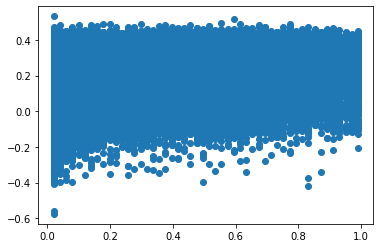

In [77]:
plt.scatter(y, res.predict(X))
plt.show()

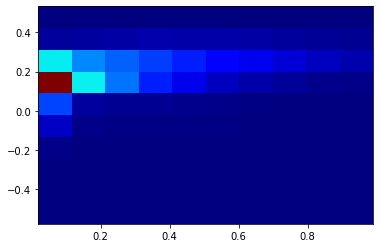

In [78]:
plt.hist2d(np.squeeze(y.to_numpy()), res.predict(X), cmap=plt.cm.jet)
plt.show()

# GLM regression

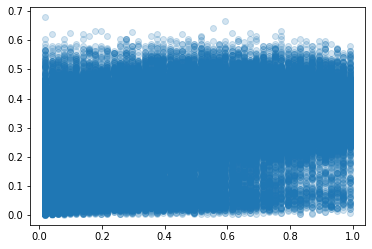

In [79]:
binom_glm = sm.GLM(y, X, family=sm.families.Binomial())
binom_reg = binom_glm.fit()

plt.plot(y, binom_reg.predict(X), 'o', alpha=0.2);

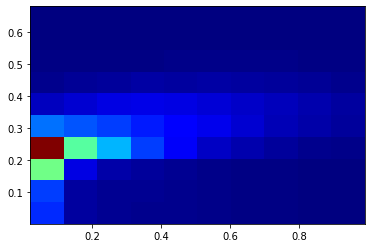

In [80]:
plt.hist2d(np.squeeze(y.to_numpy()), binom_reg.predict(X), cmap=plt.cm.jet)
plt.show()

In [51]:
# libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kde

In [52]:
y.shape

(281486, 1)

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(r2_score(y, binom_reg.predict(X)))
print(mean_squared_error(y, binom_reg.predict(X)))
print(mean_absolute_error(y, binom_reg.predict(X)))

0.2044574557200195
0.04627003987914166
0.16963605409318783


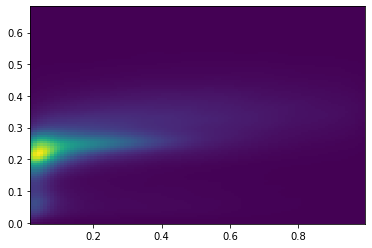

In [54]:
# Evaluate a gaussian kde on a regular grid of nbins x nbins over data extents
nbins=100
y = np.squeeze(y)
y_pred = np.array(binom_reg.predict(X))

k = kde.gaussian_kde([y, y_pred])
xi, yi = np.mgrid[y.min():y.max():nbins*1j, y_pred.min():y_pred.max():nbins*1j]
zi = k(np.vstack([xi.flatten(), yi.flatten()]))

# Make the plot
plt.pcolormesh(xi, yi, zi.reshape(xi.shape), shading='auto')
plt.show()

# multivariate Spline regression

In [62]:
from pyearth import Earth

model = Earth(max_degree =3)
model.fit(X,y)

Earth(max_degree=3)

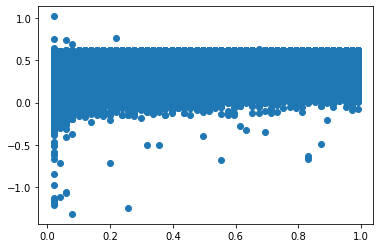

In [63]:
plt.scatter(y, model.predict(X))
plt.show()

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(r2_score(y, model.predict(X)))
print(mean_squared_error(y, model.predict(X)))
print(mean_absolute_error(y, model.predict(X)))

0.3753410116788293
0.036331176136713106
0.14302443558196726


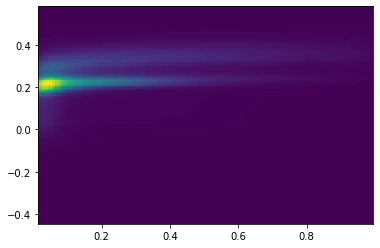

In [58]:
# Evaluate a gaussian kde on a regular grid of nbins x nbins over data extents
nbins=100
y = np.squeeze(y)
y_pred = np.array(model.predict(X))

k = kde.gaussian_kde([y, y_pred])
xi, yi = np.mgrid[y.min():y.max():nbins*1j, y_pred.min():y_pred.max():nbins*1j]
zi = k(np.vstack([xi.flatten(), yi.flatten()]))
 
# Make the plot
plt.pcolormesh(xi, yi, zi.reshape(xi.shape), shading='auto')
plt.show()

# beta regression

In [69]:
from scipy.special import loggamma
from scipy.special import expit, logit

def logLikelihood(params, y, X):
    b = np.array(params[0:-1])      # the beta parameters of the regression model
    phi = params[-1]                # the phi parameter
    mu = expit(np.dot(X,b))
   
    eps = 1e-6                      # used for safety of the gamma and log functions avoiding inf
    res = - np.sum(loggamma(phi+eps) # the log likelihood
                   - loggamma(mu*phi+eps) 
                   - loggamma((1-mu)*phi+eps) 
                   + (mu*phi-1)*np.log(y+eps) 
                   + ((1-mu)*phi-1)*np.log(1-y+eps))

    return res

In [74]:
from scipy.optimize import minimize

# initial parameters for optimization
phi = 1
b0 = 1
x0 = np.array([b0,b0,b0,b0,phi])

res = minimize(logLikelihood, x0=x0, args=(y,X), bounds=[(None,None), 
                                                         (None,None), 
                                                         (None,None), 
                                                         (None,None), 
                                                         (None,None), 
                                                         (0,None)])

ValueError: length of x0 != length of bounds

# log count

In [50]:
frag_cut_df3 = frag_cut_df.loc[frag_cut_df.loc[:,"log_count"] < max_log_coverage,:]
frag_cut_df3.loc[:, "relative_depth"] = frag_cut_df3.loc[:, "log_count"]/max_log_coverage

/home/wbguo/.local/lib/python3.8/site-packages/pandas/core/indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


In [51]:
frag_cut_df3

,chr,ref_l,ref_r,count,length,gc_ratio,CCGG,log_count,relative_depth
0,chr1,51586.0,51724.0,106,138.0,0.623188,2,6.741467,0.811354
1,chr1,88703.0,88853.0,10,150.0,0.666667,2,3.459432,0.416352
2,chr1,134997.0,135219.0,6,222.0,0.671171,2,2.807355,0.337873
3,chr1,137975.0,138268.0,1,293.0,0.672355,2,1.000000,0.120353
4,chr1,181322.0,181574.0,1,252.0,0.726190,2,1.000000,0.120353
...,...,...,...,...,...,...,...,...,...
293024,chrY,24276285.0,24276458.0,11,173.0,0.653179,2,3.584963,0.431460
293025,chrY,26403637.0,26404260.0,2,623.0,0.646870,2,1.584963,0.190755
293026,chrY,26610489.0,26611056.0,22,567.0,0.470899,2,4.523562,0.544423
293027,chrY,56874939.0,56875077.0,3,138.0,0.521739,2,2.000000,0.240706


In [53]:
frag_cut_df3.loc[:, 'log_count'].describe()

count    292850.000000
mean          3.291732
std           1.505446
min           1.000000
25%           2.000000
50%           3.459432
75%           4.523562
max           8.308339
Name: log_count, dtype: float64

In [54]:
frag_cut_df3.gc_ratio.describe()

count    292850.000000
mean          0.586433
std           0.083394
min           0.265625
25%           0.528986
50%           0.574141
75%           0.644531
max           0.972973
Name: gc_ratio, dtype: float64

<AxesSubplot:>

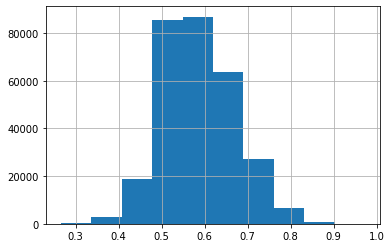

In [55]:
frag_cut_df3.gc_ratio.hist()

In [56]:
frag_cut_df3.relative_depth.describe()

count    292850.000000
mean          0.396169
std           0.181185
min           0.120353
25%           0.240706
50%           0.416352
75%           0.544423
max           0.999932
Name: relative_depth, dtype: float64

<AxesSubplot:>

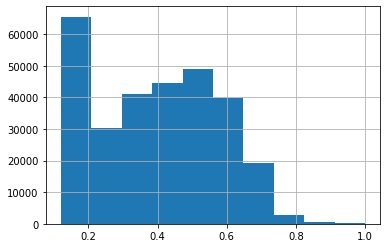

In [57]:
frag_cut_df3.relative_depth.hist()

In [58]:
frag_cut_df3.CCGG.describe()

count    292850.000000
mean          2.021202
std           0.147107
min           2.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           7.000000
Name: CCGG, dtype: float64

<AxesSubplot:>

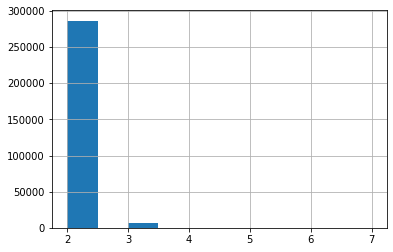

In [59]:
frag_cut_df3.CCGG.hist()

In [60]:
frag_cut_df3.length.describe()

count    292850.000000
mean        191.159361
std         105.165884
min         104.000000
25%         134.000000
50%         158.000000
75%         207.000000
max        1033.000000
Name: length, dtype: float64

<AxesSubplot:>

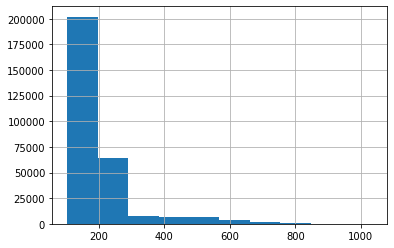

In [61]:
frag_cut_df3.length.hist()

<AxesSubplot:>

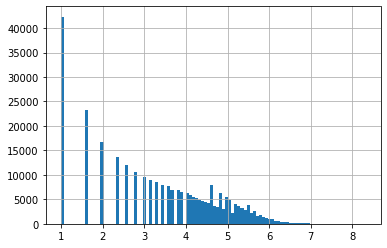

In [62]:
frag_cut_df3.loc[:, 'log_count'].hist(bins=100)

<AxesSubplot:>

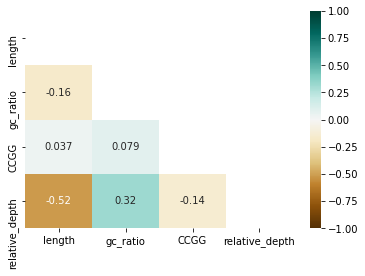

In [63]:
import seaborn as sns
%matplotlib inline

corr = frag_cut_df3.loc[frag_cut_df3.loc[:,"log_count"]>0,["length","gc_ratio", "CCGG", "relative_depth"]].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

# plot the heatmap
sns.heatmap(corr,  vmin=-1, vmax=1, annot=True, cmap='BrBG', mask=mask,
            xticklabels=corr.columns,
            yticklabels=corr.columns)

In [64]:
y, X = dmatrices('relative_depth ~ gc_ratio + length + CCGG', 
                 data = frag_cut_df3,
                 return_type='dataframe')

mod = sm.OLS(y, X)
mod = mod.fit()
print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:         relative_depth   R-squared:                       0.177
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                 2.103e+04
Date:                Thu, 23 Feb 2023   Prob (F-statistic):               0.00
Time:                        17:46:11   Log-Likelihood:             1.1329e+05
No. Observations:              292850   AIC:                        -2.266e+05
Df Residuals:                  292846   BIC:                        -2.265e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4975      0.005    107.752      0.0

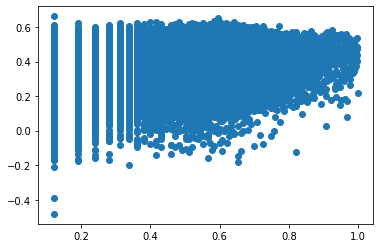

In [65]:
plt.scatter(y, mod.predict(X))
plt.show()

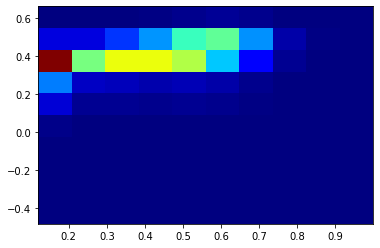

In [66]:
plt.hist2d(np.squeeze(y.to_numpy()), mod.predict(X), cmap=plt.cm.jet)
plt.show()

In [67]:
mod = smf.quantreg('relative_depth ~ CCGG + length + gc_ratio', frag_cut_df3)
res = mod.fit(q=.5)
print(res.summary())

                         QuantReg Regression Results                          
Dep. Variable:         relative_depth   Pseudo R-squared:               0.1331
Model:                       QuantReg   Bandwidth:                     0.01298
Method:                 Least Squares   Sparsity:                       0.4493
Date:                Thu, 23 Feb 2023   No. Observations:               292850
Time:                        17:46:28   Df Residuals:                   292846
                                        Df Model:                            3
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6010      0.006     95.236      0.000       0.589       0.613
CCGG          -0.2368      0.003    -83.308      0.000      -0.242      -0.231
length        -0.0006   4.09e-06   -155.881      0.000      -0.001      -0.001
gc_ratio       0.6825      0.005    132.163      0.0

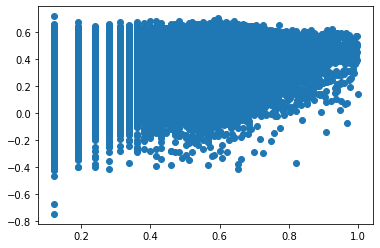

In [68]:
plt.scatter(y, res.predict(X))
plt.show()

# neural network

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

np.random.seed(0)
rand_idx = np.random.choice(frag_cut_df2.index, size=1000, replace=False)

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(frag_cut_df2.loc[rand_idx, ['gc_ratio', 'length', 'CCGG']], 
                                                    frag_cut_df2.loc[rand_idx, 'relative_depth'], test_size=0.3, random_state=42)

# standardize the training data
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)

# apply the same standardization to the testing data
X_test_std = scaler.transform(X_test)

In [ ]:
X_train_std

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt

# Define the neural network architecture
model = Sequential()
model.add(Dense(, input_dim=3, activation='relu'))
model.add(Dense(64))
model.add(Dense(1))

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model and plot the learning loss
history = model.fit(X_train, y_train, epochs=100, batch_size=512, validation_data=(X_test, y_test), verbose=0)

In [ ]:
plt.plot(history.history['loss'], label='training')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Learning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# kernel regression

In [ ]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Define the parameter grid for hyperparameter tuning
param_grid = {'alpha': np.logspace(-3, 3, 7),
              'kernel': ['linear', 'rbf', 'poly']}

# Define the cross-validation strategy
cv = KFold(n_splits=10)

# Create a kernel ridge regression model
clf = KernelRidge()

# Perform grid search cross-validation to select hyperparameters
grid_search = GridSearchCV(clf, param_grid=param_grid, cv=cv, scoring='neg_mean_squared_error')
grid_search.fit(X_train_std, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_

# Create a new kernel ridge regression model with the best hyperparameters
clf = KernelRidge(alpha=best_params['alpha'], kernel=best_params['kernel'])

# Fit the model to the data
clf.fit(X_train_std, y_train)

# Predict on new data
# y_pred = clf.predict(X)

# Compute the mean squared error on the test set
mse = mean_squared_error(y_train, clf.predict(X_train_std))

In [ ]:
# Plot the mean squared error as a function of alpha
alphas = np.logspace(-3, 3, 7)
mse_values = -grid_search.cv_results_['mean_test_score']
plt.plot(alphas, mse_values)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.show()

In [ ]:
mse_values = -grid_search.cv_results_['mean_test_score']

In [ ]:
alphas 

In [ ]:
mse_values

In [ ]:
best_params

In [ ]:
clf.

# save and load

In [ ]:
filename = 'rrbs_model.sav'
pickle.dump(clf, open(filename, 'wb'))
 
# some time later...
 
# load the model from disk
clf = pickle.load(open(filename, 'rb'))
relative_score = clf.predict(X_new)

In [ ]:
np.sum(frag_df.flag_start + frag_df.flag_end != 0)

# Misc

In [ ]:
is_upstream = False
pos = 182849
contig_id ='chr1'

In [ ]:
find_closest_cut(contig_id, pos, site_list, is_upstream = is_upstream)

In [ ]:
pos + pos_arr[np.argmin(np.abs(pos_arr))]

In [ ]:
ref_dict[contig_id][51586:51586]

In [ ]:
find_closest_cut('chr1',51587, site_list, is_upstream=True)

In [ ]:
read_gen = read_pair_generator(bam_file, 'chr21')

In [ ]:
read1, read2 = next(read_gen)

In [ ]:
read1.reference_start

In [ ]:
read1.reference_end

In [ ]:
read2.reference_start

In [ ]:
read2.reference_end

In [ ]:
read1.mapq

In [ ]:
read1.cigar

In [ ]:
read1.query_name

In [ ]:
read2.query_name

In [ ]:
read1.aligned_pairs

In [ ]:
bam = pysam.AlignmentFile(bam_file, "rb")

for _, reads in itertools.groupby(bam.fetch(), key=lambda x: x.query_name):
    reads = list(reads)
    if len(reads) == 2:
        read1, read2 = reads
        if read1.is_read1 and read2.is_read2 and read1.reference_name == read2.reference_name:
            print("Pair:", read1.query_name)
            print("Read 1:", read1.query_name, read1.reference_start, read1.reference_end)
            print("Read 2:", read2.query_name, read2.reference_start, read2.reference_end)
            break

In [ ]:
read1.aend

In [ ]:
read1.reference_end

In [ ]:
read1.cigarstring

In [ ]:
read1.reference_start

In [ ]:
read1.aligned_pairs

In [ ]:
reads[0].seq

In [ ]:
reads[0].reference_name

In [ ]:
ref_dict[reads[0].reference_name][reads[0].reference_start:reads[0].reference_end]

In [ ]:
ref_dict[reads[1].reference_name][reads[1].reference_start:reads[1].reference_end]

In [ ]:
print(reads[0].query_name)